In [11]:
import json
import requests
from pathlib import Path

import duckdb
import polyline
from geopy.distance import geodesic

from to_gpx import to_gpx

In [12]:
DATA_BASE_PATH = Path("./data").resolve().absolute()
GRAPHHOPPER_BASE_URL = "http://localhost:8989"
GPS_ACCURACY = 50

In [13]:
gps_data_path = DATA_BASE_PATH / "gps_data.parquet"
ground_truth_path = DATA_BASE_PATH / "ground_truth_route.parquet"
newson_krumm_route_network_path = DATA_BASE_PATH / "road_network.parquet"

In [14]:
ground_truth_df = duckdb.query(
    f"""
    SELECT gt.edge_id, traversed, linestring 
    FROM '{ground_truth_path}' gt 
    JOIN '{newson_krumm_route_network_path}' nkr 
    ON gt.edge_id = nkr.edge_id
    WHERE gt.traversed = 1
    """
).to_df()

In [15]:
ground_truth_df["track_segs"] = ground_truth_df["linestring"].str.replace(
    r"^LINESTRING\(|\)$", "", regex=True
)
ground_truth_df["track_segs"] = (
    ground_truth_df["track_segs"].str.replace(",", ";").replace(r"\s+", " ", regex=True)
)
ground_truth_df["track_segs"] = ground_truth_df["track_segs"].str.split(";")
ground_truth_df["track_segs"] = ground_truth_df["track_segs"].apply(
    lambda x: [tuple(float(coord) for coord in point.split()) for point in x]
)
ground_truth_df["track_segs"]

0      [(-122.349758148193, 47.6465114951134), (-122....
1      [(-122.34973937273, 47.6461198925972), (-122.3...
2      [(-122.356890141964, 47.6449799537659), (-122....
3      [(-122.356908917427, 47.6432499289513), (-122....
4      [(-122.356908917427, 47.6441296935081), (-122....
                             ...                        
396    [(-122.141988873482, 47.6346802711487), (-122....
397    [(-122.143048346043, 47.6342108845711), (-122....
398    [(-122.099888920784, 47.5678691267967), (-122....
399    [(-122.144249975681, 47.633650302887), (-122.1...
400    [(-122.149338126183, 47.6307910680771), (-122....
Name: track_segs, Length: 401, dtype: object

In [16]:
gps_df = duckdb.query(f"SELECT * FROM '{gps_data_path}'").to_df()
gps_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7531 entries, 0 to 7530
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   recorded_timestamp  7531 non-null   datetime64[us]
 1   lon                 7531 non-null   float64       
 2   lat                 7531 non-null   float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 176.6 KB


In [17]:
gps_df.head()

,recorded_timestamp,lon,lat
0,2009-01-17 20:27:37,-122.107083,47.667483
1,2009-01-17 20:27:38,-122.107067,47.667500
2,2009-01-17 20:27:39,-122.107067,47.667500
3,2009-01-17 20:27:40,-122.107033,47.667517
4,2009-01-17 20:27:41,-122.106983,47.667533


In [18]:
points = gps_df[["lon", "lat", "recorded_timestamp"]].to_numpy()

gpx_path = to_gpx(points, DATA_BASE_PATH / "gps.gpx")

In [19]:
def request_map_matching(point_gpx_path: Path, output_path: Path) -> str:
    url = f"{GRAPHHOPPER_BASE_URL}/match?profile=car&gps_accuracy={GPS_ACCURACY}&type=json&locale=pt_BR&details=edge_id"
    headers = {
        "Content-Type": "application/gpx+xml",
    }

    with open(point_gpx_path, "rb") as f:
        body = f.read()

    req = requests.post(
        url,
        headers=headers,
        data=body,
    )

    req.raise_for_status()

    with open(output_path, "wb") as f:
        f.write(req.content)

    print(f"Map matching result saved to {output_path}")

    res =  json.loads(req.content)["paths"][0]

    return {
        "points": res["points"],
        "edge_ids": res["details"]["edge_id"],
    }

In [20]:
graphhopper_result = request_map_matching(
    point_gpx_path=gpx_path, output_path=DATA_BASE_PATH / "map_matched.json"
)
graphhopper_result

Map matching result saved to /home/jose_edsouza/Documentos/Faculdade/TCC/repo/dataset/newson-krumm/data/map_matched.json


{'points': 'aa}aHf`hhV?sG?{@EcD?q@@yG@mBKk@KSm@hAo@rAm@vAe@pAa@nA_@pA?@EFk@t@a@`@g@\\}@b@iCrAYTKHW`@Qj@Ih@?b@?RB`@BTJd@P^XX\\VhAl@d@V`CrA~@f@l@d@f@n@JT|@hBh@fBXj@h@tAV~@h@`C@HFfAJrD?X?jH??AjHAnHCnHAlHAdHGfHIvF?f@?hBDzBBn@Dt@Dn@VnCBXTbBVzAPz@Jd@`@~Ap@tBJXh@tAx@hB^n@p@hA`BtBJLh@p@lA`Aj@^f@^|BbAtDbB`EhBdAd@l@p@pAn@lEtBlEnBt@\\lBfAXLtDhBhD~AfAh@t@^l@VTsDBc@BW@U?AB]Bg@NcCJgAN_BPsCBw@Dy@?mAEmBCc@UaEIqAQaDQiCOcCQ}CAOK}BOeCAOC{@Ge@iAwCYs@cAcC]{@[w@yAaDIOu@eAm@cAYs@g@yAY{@c@qAAEM]c@oA@Cj@q@j@o@v@y@j@o@jBuBxBcCb@c@`DyCPO|@k@`Ag@ZMd@SdAYlAWBAfAOvBW@?bBWz@MPGTGAe@@SFQn@mATk@HWPk@n@sEh@}DT_BXmB`@wC?CX{BX_BRw@Ty@To@Zm@j@w@^e@rAsAd@W^OdAWzAQ@?xC_@TExBYlAKr@KXMb@a@v@wAbAgBLWr@oA`CiEvAeCf@{@f@{@|A}CfAwBr@gBZw@n@uAd@{A\\cApAaDxAsD\\w@bCmFfCiFXm@bBaDfAmBVa@d@q@tCgDxA}A~@gAz@aA~AeB??|CkDzCeDjCyBVOt@g@zAy@ZUNILGjBi@n@ONA|ASh@C`AAV?bADdAJb@HpBp@jAl@bBrAtA~@z@l@nAr@v@Z|D`BZNv@b@dBhA~AlAvArAhAlAdArAPTp@~@`A|Ap@rAv@jBFLbBnERp@lBfG^jA|@~An@fAhDbEdD|DZ^bAzAp@rArBzFrBvFvBvFHTvAjDVp@Rb@r@pAt@zALR~BvDRVf@r@vApAl@b@

In [22]:
grapphopper_trajectory = polyline.decode(graphhopper_result["points"])

grapphopper_trajectory

[(47.66753, -122.10708),
 (47.66753, -122.1057),
 (47.66753, -122.1054),
 (47.66756, -122.10458),
 (47.66756, -122.10433),
 (47.66755, -122.10292),
 (47.66754, -122.10237),
 (47.6676, -122.10215),
 (47.66766, -122.10205),
 (47.66789, -122.10242),
 (47.66813, -122.10284),
 (47.66836, -122.10328),
 (47.66855, -122.10369),
 (47.66872, -122.10409),
 (47.66888, -122.1045),
 (47.66888, -122.10451),
 (47.66891, -122.10455),
 (47.66913, -122.10482),
 (47.6693, -122.10499),
 (47.6695, -122.10514),
 (47.66981, -122.10532),
 (47.6705, -122.10574),
 (47.67063, -122.10585),
 (47.67069, -122.1059),
 (47.67081, -122.10607),
 (47.6709, -122.10629),
 (47.67095, -122.1065),
 (47.67095, -122.10668),
 (47.67095, -122.10678),
 (47.67093, -122.10695),
 (47.67091, -122.10706),
 (47.67085, -122.10725),
 (47.67076, -122.10741),
 (47.67063, -122.10754),
 (47.67048, -122.10766),
 (47.67011, -122.10789),
 (47.66992, -122.10801),
 (47.66927, -122.10843),
 (47.66895, -122.10863),
 (47.66872, -122.10882),
 (47.66852

In [23]:
real_trajectory = (
    ground_truth_df["track_segs"].explode().apply(lambda x: (x[1], x[0])).tolist()
)
real_trajectory

[(47.6465114951134, -122.349758148193),
 (47.6469111442566, -122.349768877029),
 (47.6461198925972, -122.34973937273),
 (47.6465114951134, -122.349758148193),
 (47.6449799537659, -122.356890141964),
 (47.6458194851875, -122.356879413128),
 (47.6432499289513, -122.356908917427),
 (47.6441296935081, -122.356908917427),
 (47.6441296935081, -122.356908917427),
 (47.6449799537659, -122.356890141964),
 (47.6414394378662, -122.356919646263),
 (47.6432499289513, -122.356908917427),
 (47.639591395855, -122.356919646263),
 (47.6414394378662, -122.356919646263),
 (47.6383709907532, -122.356930375099),
 (47.639591395855, -122.356919646263),
 (47.6371800899506, -122.356938421726),
 (47.6383709907532, -122.356930375099),
 (47.63671875, -122.356935739517),
 (47.6371800899506, -122.356938421726),
 (47.6492205262184, -122.349768877029),
 (47.6495799422264, -122.349790334702),
 (47.6495799422264, -122.349790334702),
 (47.6501592993736, -122.349819839001),
 (47.6501592993736, -122.349819839001),
 (47.650

In [24]:
len(real_trajectory), len(grapphopper_trajectory)

(1401, 1905)

In [26]:
def calculate_distance(trajectory: list[tuple[float, float]]) -> float:
    return sum(
        geodesic(trajectory[i], trajectory[i + 1]).meters
        for i in range(len(trajectory) - 1)
    )

In [27]:
real_length = calculate_distance(real_trajectory)
print(f"Comprimento da trajetória real: {real_length:.2f} metros")

Comprimento da trajetória real: 372237.90 metros


In [28]:
graphhopper_length = calculate_distance(grapphopper_trajectory)
print(f"Comprimento da trajetória do GraphHopper: {graphhopper_length:.2f} metros")

Comprimento da trajetória do GraphHopper: 80823.44 metros


In [29]:
graphhopper_length / real_length

0.21712845340870215

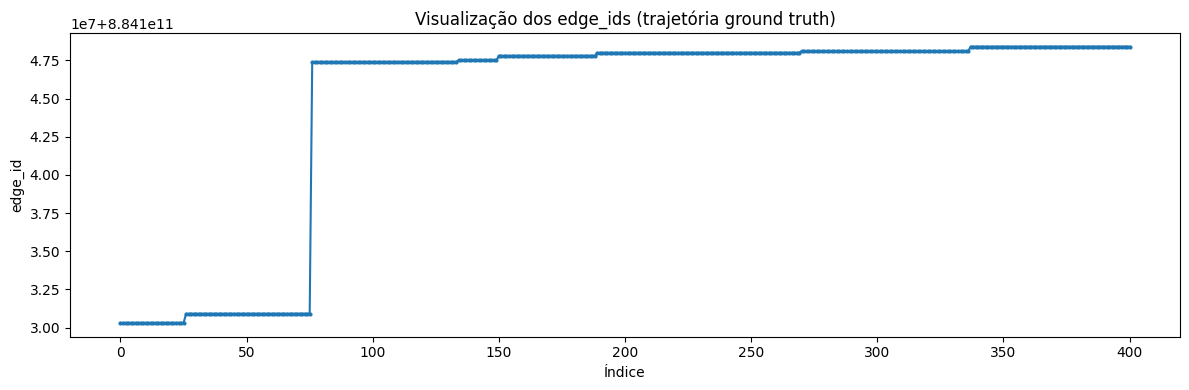

In [30]:
import matplotlib.pyplot as plt

# Visualizar os edge_ids presentes no ground_truth_df
plt.figure(figsize=(12, 4))
plt.plot(ground_truth_df["edge_id"], marker='o', linestyle='-', markersize=2)
plt.title("Visualização dos edge_ids (trajetória ground truth)")
plt.xlabel("Índice")
plt.ylabel("edge_id")
plt.tight_layout()
plt.show()